# Model Fitness: retención de clientes

Descripción: Model Fitness, una cadena de gimnasios busca entender cómo retener a sus clientes mediante la categorización de sus clientes para poder retenerlos. 

Objetivos del análisis:
1. Predecir la probabliidad de pérdidade cada cliente para el próximo mes.
2. Se describen tipos de usuario
3. Se analizan los factores que implican la pérdida.
4. Se dan recomendaciones para la relación con el tipo de usuarios que más abandona.


## 1a Parte: Lectura y exploración de los datos
- Se abren los archivos con los datos
- Se revisa su estructura
- Se cargan bibliotecas requeridas
- Se diagnostica cambios necesarios de los datasets

In [1]:
# Se importan librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Se cargan datasets 
gym_churn = pd.read_csv('/datasets/gym_churn_us.csv')

# Se imprimen carcateristicas
print(f'tamaño del gym_churn:{gym_churn.shape}')
print()
gym_churn.info()
print()
print(gym_churn.sample(3))
print()
print((gym_churn.duplicated()).sum())

tamaño del gym_churn:(4000, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_tot


De esta visualización de la estructura de los datos se puede considerar que:
- No hay campos nulos ni duplicados.
- La métrica y (objetivo) es 'Churn' donde 1 es abandona y 0 es no abandona.
- No parece haber ningun tipo de dato incorrecto.


## 2a Parte: Análisis exploratorio EDA
- Se estudian los valores prmedio y la desviación estandar
- Se observan lo svalores medios de las caracteristicas (features) de cada grupo, los que abandonan y los que no ('Churn': 1 o 0)
- Se presentan histogramas las caracteristicas de ambos grupos
- Se muestra una matriz de correlación general
- Se presenta el diagnóstico del EDA.

In [2]:
# Se presentan las estadísticas descriptivas de gym_churn
print(f'Estadisticas descriptivas del dataset:  \n{gym_churn.describe()}')

Estadisticas descriptivas del dataset:  
            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.0

In [3]:
# se muestran las caracteristicas medias por grupo
print(gym_churn.groupby('Churn').mean().T)

Churn                                       0           1
gender                               0.510037    0.510839
Near_Location                        0.873086    0.768143
Partner                              0.534195    0.355325
Promo_friends                        0.353522    0.183789
Phone                                0.903709    0.902922
Contract_period                      5.747193    1.728558
Group_visits                         0.464103    0.268615
Age                                 29.976523   26.989632
Avg_additional_charges_total       158.445715  115.082899
Month_to_end_contract                5.283089    1.662582
Lifetime                             4.711807    0.990575
Avg_class_frequency_total            2.024876    1.474995
Avg_class_frequency_current_month    2.027882    1.044546


De los valores medios de las carcaterísticas se puede observar qué:
- gender y Phone: valores casi idénticos entre ambos grupos, no influyen en el churn.
- Near_Location, Partner, Promo_friends, Group_visits: tienen diferencias notables, **los que se van tienen valores más bajos en todas, sugiriendo menor vinculación con el gimnasio.**
- Contract_period, Month_to_end_contract y Lifetime: es donde están las diferencias más grandes, **los que se van tienen contratos cortos, poco tiempo restante y poca antigüedad.**
- Age: los que se van son ligeramente más jóvenes.
- Avg_class_frequency y Avg_additional_charges: **los que se van asisten menos y gastan menos en servicios extra.**

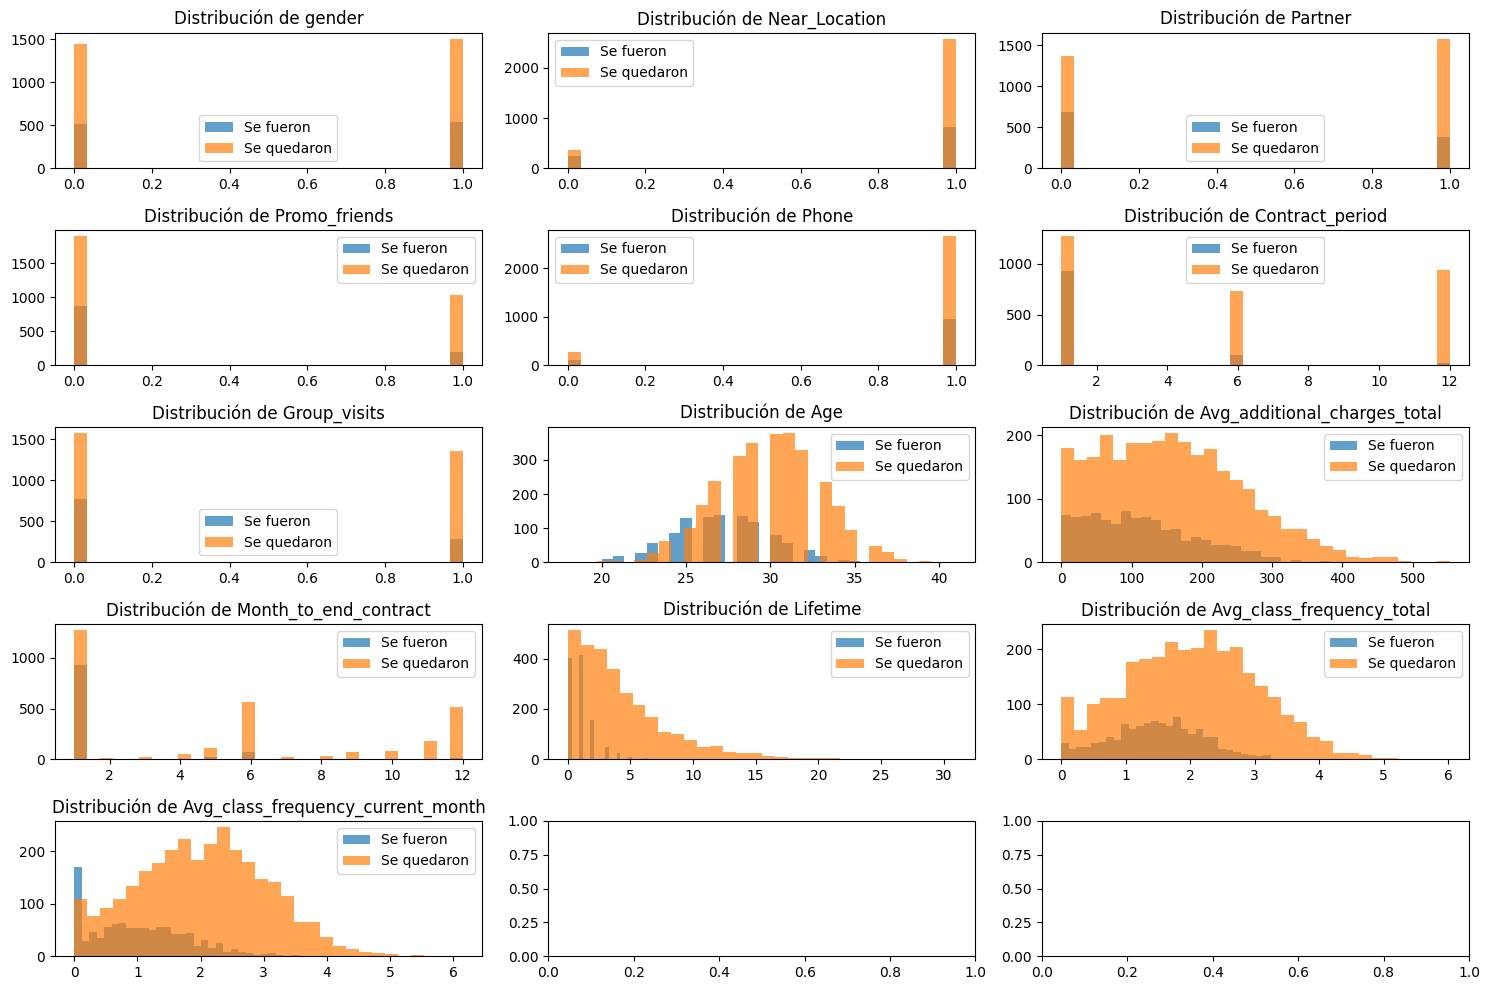

In [4]:

# Se crean dataFrames para Churn en 1 y 0
gym_churn_1 = gym_churn[gym_churn['Churn'] == 1]
gym_churn_0 = gym_churn[gym_churn['Churn'] == 0]

# Se crea una lista con los nombres de las columnas
features = gym_churn.columns.drop('Churn')

# Se prepara la figura para los histogramas
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 10))
axes = axes.flatten()

# Se hace un bucle for para cada característica 
for i, feature in enumerate(features):
    axes[i].hist(gym_churn_1[feature], bins=30, alpha=0.7, label='Se fueron')
    axes[i].hist(gym_churn_0[feature], bins=30, alpha=0.7, label='Se quedaron')
    axes[i].legend()
    axes[i].set_title(f'Distribución de {feature}')

plt.tight_layout()
plt.show()


De estos histogramas conjuntos se puede observar que:
- Confirmaron visualmente el análisis de la tabla previa: Lifetime, Month_to_end_contract y Contract_period muestran distribuciones muy distintas entre grupos.
- Las variables binarias con diferencia notable: Near_Location, Partner, Promo_friends, Group_visits.
- gender y Phone prácticamente iguales en ambos grupos, lo que implica que no son relevantes para el análisis

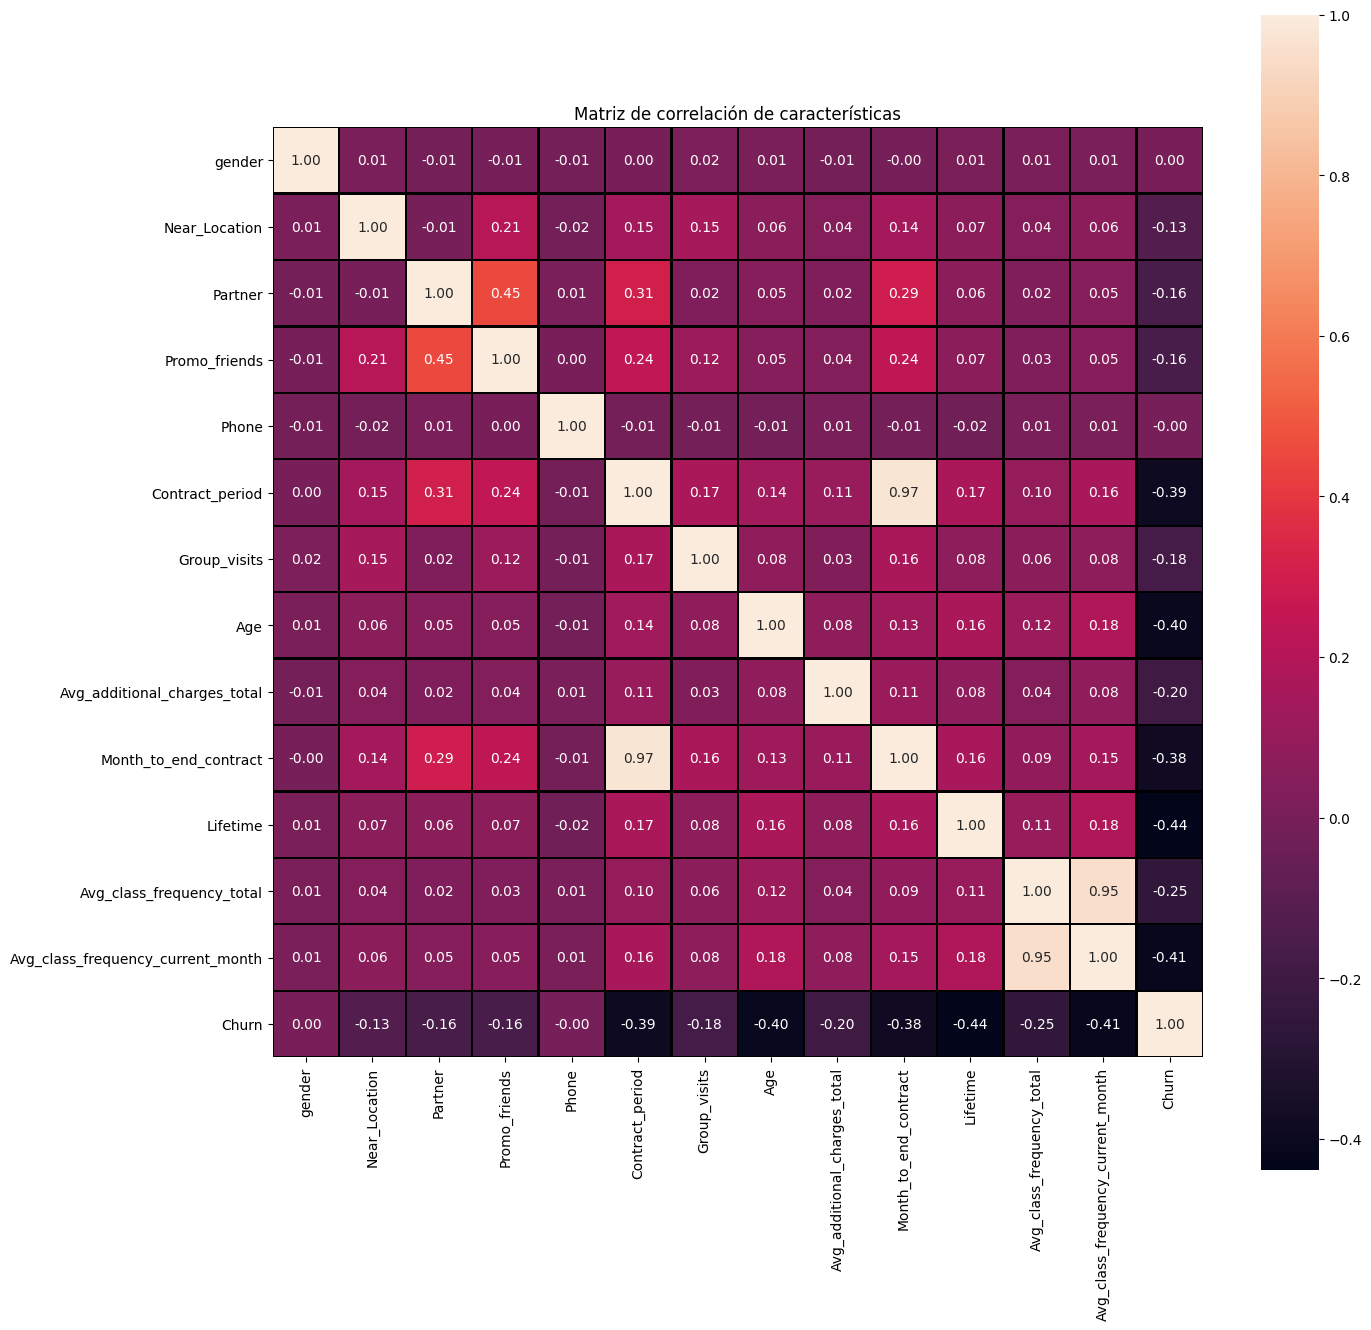

In [5]:
# se produce la matriz de correlación en un mapa de calor
plt.figure(figsize=(15, 15))
sns.heatmap(gym_churn.corr(), 
           annot=True, 
           fmt='.2f', 
           linewidths=True, 
           linecolor='black', 
           square=True)
plt.title('Matriz de correlación de características')
plt.show()

### conclusiones preliminares del EDA:
- considerando lo expuesto sobre la tabla y las distribuciones, 
- Multicolinealidad detectada: Contract_period y Month_to_end_contract (~0.97), y Avg_class_frequency_total con Avg_class_frequency_current_month (~0.95).
- características con mayor correlación absoluta con Churn: Lifetime (-0.44), Avg_class_frequency_current_month (-0.41), Age (-0.40), Contract_period (-0.39), Month_to_end_contract (-0.38).

El signo negativo indica que a mayor valor de esas features, menor probabilidad de abandono.
- como hay una correlación media con Churn podría ir dandonos pistas de hacía donde deverian dirigirse las recomendaciones pero aguardamos al análisis de clusters.

**Retrato (preliminar) del cliente que abandona:**
Joven, poca antigüedad en el gimnasio, contratos cortos, asiste poco a clases, gasta menos en servicios extra y tiene poca vinculación con otros miembros (no vino por promo_friends, no tiene partner, no hace clases grupales).

## 3a Parte: El modelo de predicción para el abandono de clientes
- Se dividen los datos para el entrenamiento.
- Se entrena el modelo con una regresión logística y con randomforest.
- Se evalúa la exactitud, precicion y recall para ambos modelos.
- Se analizan los resultados.

In [6]:

# Se crean las variables de X y y para el entrenamiento y la prueba
X = gym_churn.drop('Churn', axis=1)
y = gym_churn['Churn']

# Se divide la muestra. Notese que se usa random_state 0 para mantener una coherencia en los resultados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= .2, random_state=0)


In [7]:
# Se define el algoritmo (regresión logística) del modelo. Notese que se agreag random_state en 0.
lr_model = LogisticRegression(random_state=0, max_iter=1000)

# Se entrena con las muestras de entrenamiento de X y y
lr_model.fit(X_train, y_train)

# Se utiliza el modelo entrenado para las predicciones y probabilidades
lr_predictions = lr_model.predict(X_test)
lr_probabilities = lr_model.predict_proba(X_test)


In [8]:

# Se define el algoritmo (random_forest) del modelo. igualmente random_state en 0.
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)

#Se entrena el modelo
rf_model.fit(X_train, y_train)

#Se utiliza el modelo entrenado para las prediciones
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)


In [9]:


# Se evalúan los modelos mediante la metricas de exactitud con los datos de validación (test)
lr_acc = accuracy_score(y_test, lr_predictions)
rf_acc = accuracy_score(y_test, rf_predictions)

# Se evalúa con precisión
lr_precision = precision_score(y_test, lr_predictions)
rf_precision = precision_score(y_test, rf_predictions)

# Se evalúa con recall 
lr_recall = recall_score(y_test, lr_predictions)
rf_recall = recall_score(y_test, rf_predictions)

# Se imprimen las comparativas

print(f'Exactitud de regresión logística: {lr_acc:.2f}, de RandomForest: {rf_acc:.2f}')
print(f'Precisión de regresión logístic: {lr_precision:.2f}, de RandomForest: {rf_precision:.2f}')
print(f'Recall de regresión logística: {lr_recall:.2f}, de RandomForest: {rf_recall:.2f}')




Exactitud de regresión logística: 0.92, de RandomForest: 0.92
Precisión de regresión logístic: 0.86, de RandomForest: 0.84
Recall de regresión logística: 0.83, de RandomForest: 0.82


### Conclusiones preliminares de los modelos de predicción
- Ambos modelos demuestran que pueden acertar en su predicción el 92 % de abandono o permanencia.
- Si tomamos el modelo entrenado mediante la regresión logística, podemos considerar que del total de predicciones de abandono el 86% realmente se van. Así mismo, de los clientes que verdaderamente se van el modelo acierta el 83%.
- Con esto en mente, se puede considerar que el modelo de regresión logística es mejor pues el modelo de RandomForest tiene unas métricas de precisión y recall ligeramente inferiores.

## 4a Parte: cluster de usuarios
En esta parte del analisis:
- Se estandarizan los datos para una mejor construccion de clusters
- Se presenta el dendrogama de las distancias
- Se entrena el modelo de clustering con K-means
- Se analizan los valores medios de las características de los clusters
- Se trazan las distribuciones de esas caracteristicas
- Se observan las tasas de cancelación de los clusters creados
- Se dan conclusiones del análisis.

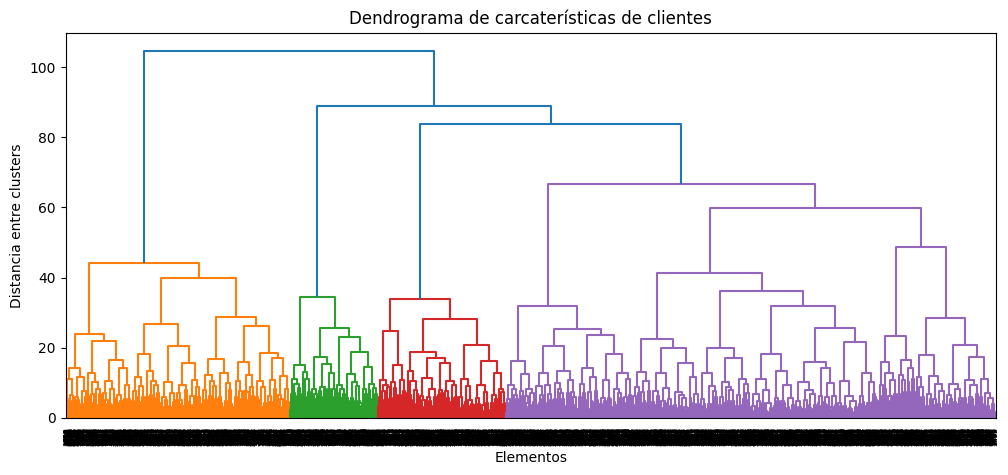

In [10]:
# Se estandarizan las características 
sc = StandardScaler()
X_sc = sc.fit_transform(X)

# Se usa la función linkage para obtener un estimado de cluster para el KMeans, se usa ward para un resultado equilibrado
linked = linkage(X_sc, method='ward')

# se traza el dendrograma
plt.figure(figsize=(12, 5))
dendrogram(linked)
plt.title('Dendrograma de carcaterísticas de clientes')
plt.xlabel('Elementos')
plt.ylabel('Distancia entre clusters')
plt.show()


In [11]:
# considerando el dendrograma se estima el número de clusters en 5. Se agrega random_state para la reproductibidad.
km = KMeans(n_clusters=5, random_state=0)

# Se asignan las etiquetas de cluster
labels = km.fit_predict(X_sc)

# Se agrega labels al DF original
gym_churn['cluster'] = labels

print(gym_churn.sample())

      gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
2803       0              1        0              0      1                1   

      Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
2803             1   31                    123.361555                    1.0   

      Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_month  \
2803         3                   0.917243                            0.88586   

      Churn  cluster  
2803      0        3  


In [12]:
# Se muestran los valores medios de las caracteristicas segun clusters
print(f'Valores medios de carcaterísticas por Cluster \n\n{gym_churn.groupby("cluster").mean().T}')

Valores medios de carcaterísticas por Cluster 

cluster                                     0           1           2  \
gender                               0.502970    0.522078    0.495050   
Near_Location                        0.959406    0.862338    0.000000   
Partner                              0.783168    0.470130    0.463366   
Promo_friends                        0.574257    0.306494    0.079208   
Phone                                1.000000    0.000000    1.000000   
Contract_period                     10.889109    4.787013    2.352475   
Group_visits                         0.542574    0.425974    0.215842   
Age                                 29.982178   29.301299   28.477228   
Avg_additional_charges_total       160.761016  143.957664  135.457501   
Month_to_end_contract                9.954455    4.475325    2.198020   
Lifetime                             4.736634    3.924675    2.809901   
Avg_class_frequency_total            1.982055    1.847220    1.660461   
Avg

De los valores medios de las características por cluster se puede deducir lo siguiente:
- Los cluster 3 y 2 tienen mayor tasa de abandono, alrededor del 50%
- Los clusters 0 y 4 no deberian priorizarse pues el porcentaje de abandono es menos del 7%
- El cluster 1 tiene una tasa de 26% podría mejorar

Al comprar estos dos clusters (2 y 3) al resto se puede ver que:
- El contrac_period del cluster 2 no es tan diferente al cluster 4 donde la tasa de abandono es sólo del 7%, lo que indica que hay otros factores relevantes para el abandono.
- En lifetime ambos clusters son los que tienen menores medias.
- En month_to_end también son los de menor media
- En las class_frequency también tienen las menores medias
  
**La diferencia clave entre el 2 y el 4 es el near_location, pues en el cluster 2 la media es 0: nadie vive cerca**
En este sentido el resto de métricas de viculación con otros miembros es la más baja, lo que fortalece las hipotesis previas.

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


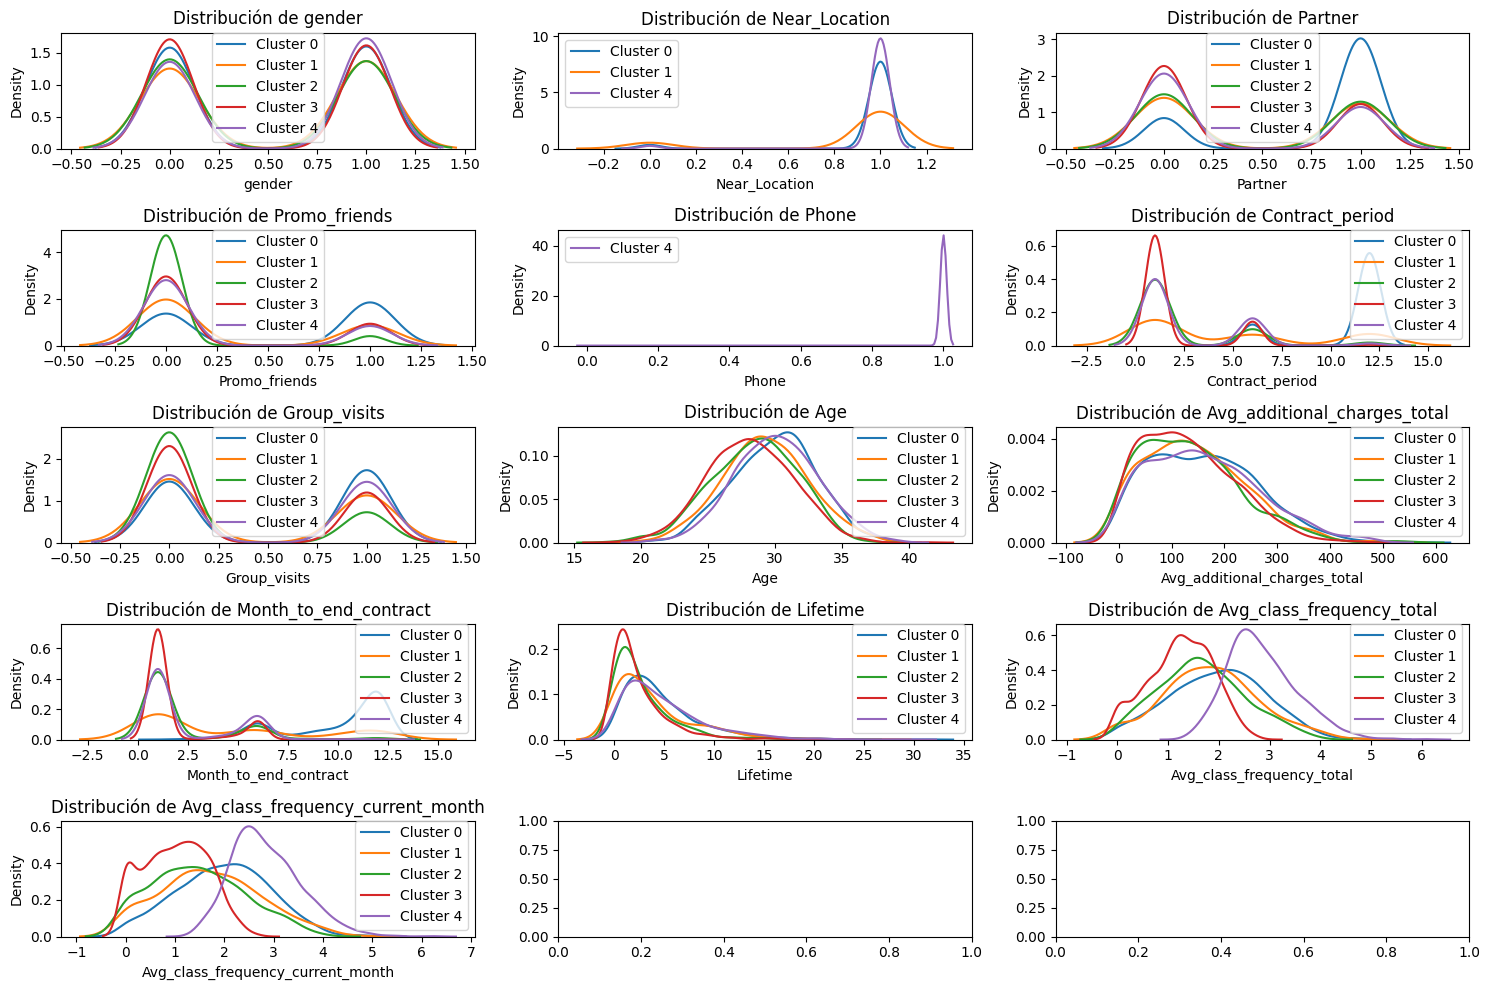

In [13]:
# Se prepara la figura para los histogramas de los clusters
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 10))
axes = axes.flatten()

# Se hace un bucle for para cada característica 
for i, feature in enumerate(features):
    for cluster in range(5):
        datos = gym_churn[gym_churn['cluster'] == cluster]
        sns.kdeplot(datos[feature], ax=axes[i], label=f'Cluster {cluster}')
    axes[i].legend()
    axes[i].set_title(f'Distribución de {feature}')

plt.tight_layout()
plt.show()

In [14]:
# Se presenta sólo la tasa de abandono por cluster
print(f'Tasa de abandono por cluster \n{gym_churn.groupby("cluster")["Churn"].mean()}')

Tasa de abandono por cluster 
cluster
0    0.027723
1    0.267532
2    0.443564
3    0.514263
4    0.068019
Name: Churn, dtype: float64


### Conclusiones preliminares a partir del clustering
- Como se señaló con los valores medios de las caracteristicas por cluster, **los grupos a considerar para buscar su retención deberian ser el 2 y el 3**
- De igual forma el 1 pero con menor prioridad
  
De las distribuciones de las carcateristicas por cluster podemos ver que:
- La diferencia de edad es minima, aunque son más jovenes
- tiene contratos cortos y son de recién ingreso
- toman menos clases que el resto
- gastan menos dinero que otros clusters

Aunque el periodo de contrato para el cluster 2 no es tan distinto del 4 (con mayor tasa de retención) se observa que los usuarios del 2 no tienen una sucursal cerca. Lo que podría ser crucial para su abandono.

El cluster 4 muestra que en aquellos que tienden a tomar más clases tienen una tasa de retención alta.

Tanto las medias como las distribuciones apoyan estos puntos.

# 5a Parte: Conlusiones y recomendaciones
Aspectos generales sobre el análisis y el modelo de predicción:
- Se puede considerar que es un modelo útil y eficiente.
- Las acciones para mantener a los usuarios futuros con base en el pronostico del modelo deberán considerar sus porcentajes de acierto respecto a los falsos negativos.

Sobre el análisis de clusters:
El usuario que abandona puede confirmarse, en general como: _Joven, poca antigüedad en el gimnasio, contratos cortos, asiste poco a clases, gasta menos en servicios extra y tiene poca vinculación con otros miembros (no vino por promo_friends, no tiene partner, no hace clases grupales)._

Sin embargo, esto puede desglosarse en estartegías especificas para la retención de cada tipo de usuario con base en los clusters:

**Cluster 2 (churn ~44%)**: 
- Ninguno vive cerca del gimnasio
- Contratos cortos (similar al cluster 4 pero sin la cercanía)
- Poca frecuencia de clases
- Poca antigüedad

**Acción sugerida:** Promocionar clases grupales, visitas con compañeros, mayores beneficios por referidos y contratos largos con descuento. Al no poder construir más sucursales cerca de ellos, _como medida adicional, y aunque el precio no es una variable del dataset, se podría explorar un descuento por distancia para incentivar la asistencia de este grupo._

**Cluster 3 (churn ~51%)**:
-Los más jóvenes
-Menor antigüedad de todos
-Contratos más cortos
-Menor frecuencia de clases
-Menor gasto en servicios extra

**Acción sugerida:** incentivar contratos más largos desde el inicio, promover referenciados y clases grupales, descuentos en sucursal (Avg_additional_charges_total) para incentivar y aumentar vinculación con el gimnasio y la comunidad.

**Cluster 1 (churn ~27%)**:
- Valores intermedios en general
- Phone = 0 — no tienen teléfono registrado
- Tienen más tiempo de contrato que clusters 2 y 3 pero menos frecuencia de clases que cluster 4
- 
**Acción sugerida:** conseguir su número de contacto para comunicación directa; incentivar mayor asistencia a clases, pues se ha visto que grupos con más clases tienden a mantenerse


**Recomendación en captación:** segmentar promocion para nuevos usuarios por cercanía geográfica para evitar usuarios sin sucursales cerca, pues suelen abandonar.